In [34]:
from google_play_scraper import Sort, reviews_all
import pandas as pd

In [35]:
def scrape_reviews(app_id):
    reviews = reviews_all(
        app_id, 
        sleep_milliseconds=0,
        lang='id',
        country='id',
        sort=Sort.NEWEST
    )
    #Extract relevant fields
    data = {
    'created_at':[review['at'] for review in reviews],
    'score' : [review['score']for review in reviews],
    'content' : [review['content'] for review in reviews],
    'thumbsUpCount' : [review['thumbsUpCount']for review in reviews]
    }

    #Create DataFrame
    df_reviews = pd.DataFrame(data)
    return df_reviews

#Example usage 
app_id = 'blibli.mobile.commerce'  # Replace with the actual app ID
df_reviews = scrape_reviews(app_id)
df_reviews.to_csv('blibli.csv', index=True)
print(df_reviews)

                created_at  score  \
0      2026-03-28 18:48:09      5   
1      2026-03-28 17:03:38      5   
2      2026-03-28 17:01:27      5   
3      2026-03-28 12:55:22      5   
4      2026-03-28 05:50:53      5   
...                    ...    ...   
150121 2013-12-28 21:33:34      5   
150122 2013-12-25 04:47:10      5   
150123 2013-12-21 02:22:57      1   
150124 2013-12-19 17:44:55      5   
150125 2013-12-11 17:29:12      5   

                                                  content  thumbsUpCount  
0                              tidak bisa bayar di tempat              0  
1                                  keren dan no tipu tipu              0  
2                       produknya tdk pernah mengecewakan              0  
3       solusi untuk beli barang secara online terbaik...              0  
4                                     mudah dan responsif              0  
...                                                   ...            ...  
150121                        

In [38]:
#Read the CSV file 
df_blibli = pd.read_csv('blibli.csv')
df_blibli.head()

,Unnamed: 0,created_at,score,content,thumbsUpCount
0,0,2026-03-28 18:48:09,5,tidak bisa bayar di tempat,0
1,1,2026-03-28 17:03:38,5,keren dan no tipu tipu,0
2,2,2026-03-28 17:01:27,5,produknya tdk pernah mengecewakan,0
3,3,2026-03-28 12:55:22,5,solusi untuk beli barang secara online terbaik...,0
4,4,2026-03-28 05:50:53,5,mudah dan responsif,0


C:\Users\USER\AppData\Local\Temp\ipykernel_1332\2201445556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


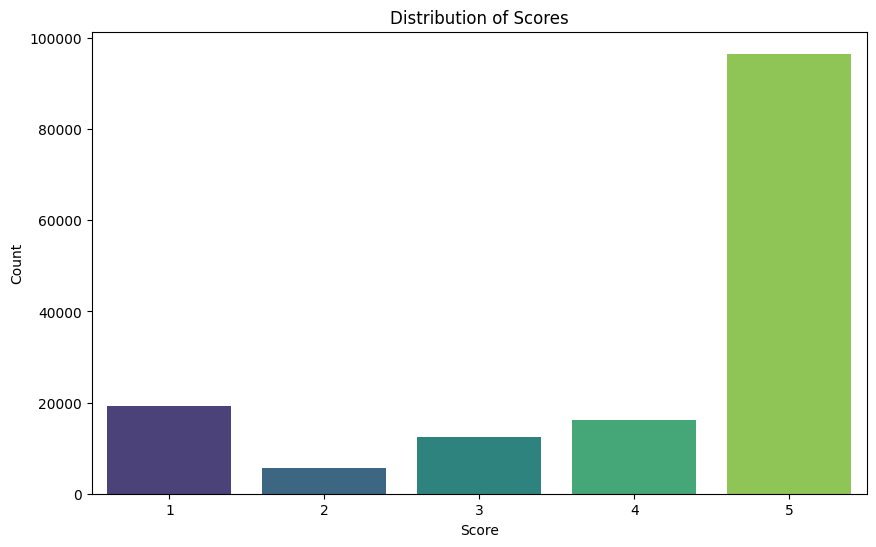

In [39]:
#Statistik deskriptif 
score_counts = df_blibli['score'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

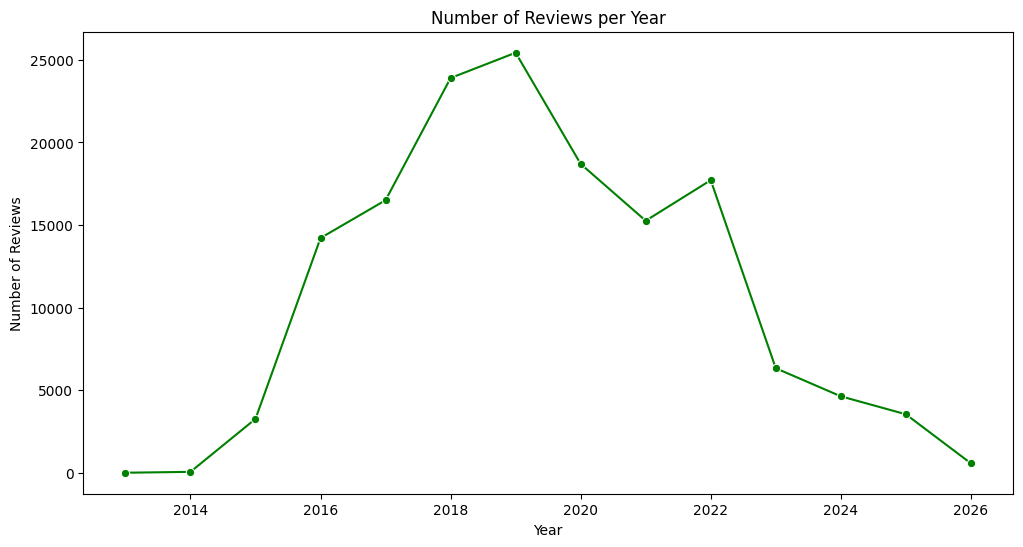

In [40]:
df_blibli['created_at'] = pd.to_datetime(df_blibli['created_at'])
df_blibli['year'] = df_blibli['created_at'].dt.year
year_counts = df_blibli['year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

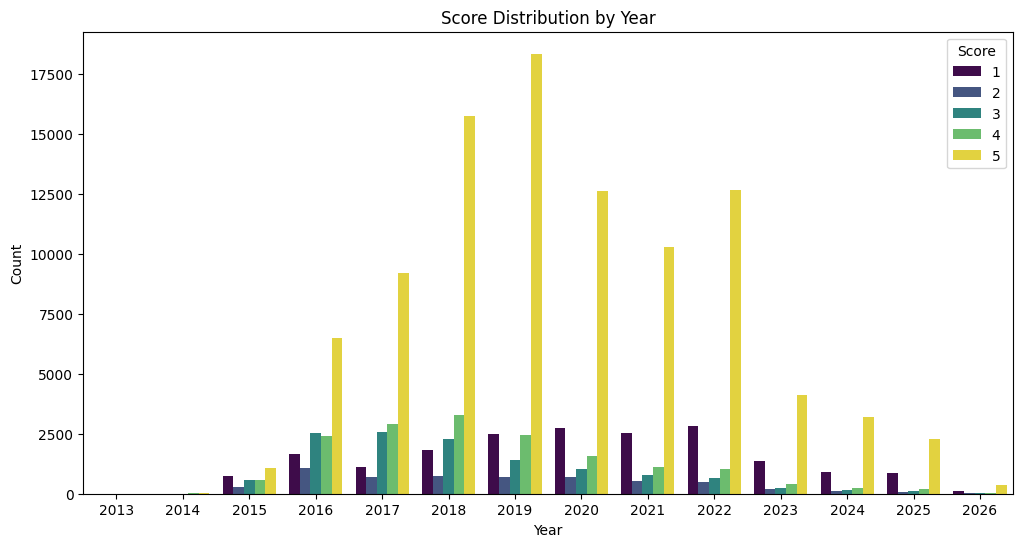

In [41]:
# Cross tabulasi antara 'year' dan 'score'
plt.figure(figsize=(12, 6))
sns.countplot(x='year', hue='score', data=df_blibli, palette='viridis')
plt.title('Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

In [43]:
!pip install wordcloud
from wordcloud import WordCloud

In [44]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

# Filter positive and negative reviews
positive_reviews = df_blibli[df_blibli['score'] >= 4]['content'].dropna()
negative_reviews = df_blibli[df_blibli['score'] <= 3]['content'].dropna()

# Combine all positive and negative reviews into single strings
positive_text = ' '.join(positive_reviews)
negative_text = ' '.join(negative_reviews)

# Remove stopwords from the combined texts
positive_text = remove_stopwords(positive_text)
negative_text = remove_stopwords(negative_text)

# Generate word clouds
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


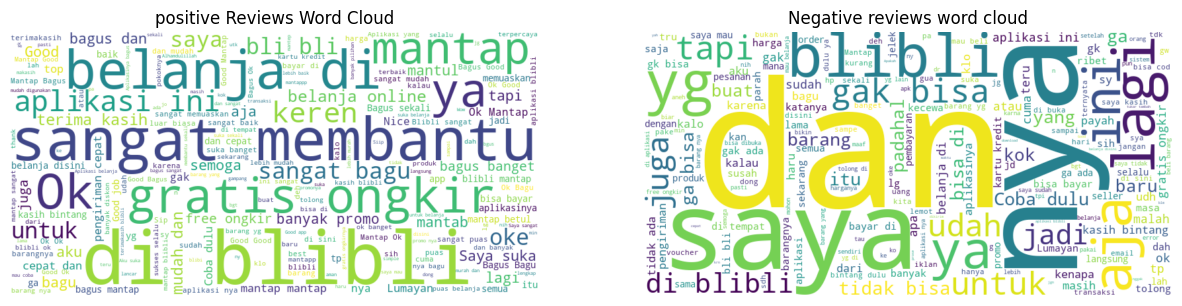

In [45]:
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('positive Reviews Word Cloud')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative reviews word cloud')
plt.axis('off')
plt.show()